# Error Propagation, Three Languages: What Operator Overloading Actually Buys You

`dgs/error_propagation.py`'s worked example -- $\text{emf}=Bhv$ (Griffiths
7.13), relative uncertainties adding in quadrature -- is implemented here
identically in **Python**, **C**, and **C++**, compiled and run for real
(not just described), to make a genuine language-FORMALISM point: C has no
operator overloading, so combining two uncertain quantities' errors MUST be
an explicit function call, `measurement_mul(a, b)`. C++ has operator
overloading, so the identical logic reads as `a * b` -- syntactically
identical to Python's `Measurement.__mul__`. All three are cross-checked to
agree to near machine precision, proving the language difference is purely
ERGONOMIC (what syntax you're allowed to write), not a difference in what
gets computed. Engine: `dgs/error_propagation_polyglot.py`.


In [1]:
%matplotlib inline
import sys, pathlib, tempfile
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt

from dgs import error_propagation_polyglot as epp
from dgs.error_propagation import Measurement, propagate, product_rule

print('Setup complete.')


Setup complete.


## 1. Theory: Propagation of Errors, and What "Operator Overloading" Formally Means

**Error propagation**: for $f(x_1,\dots,x_n)$ with independent uncertain
inputs, the first-order (linearized) output uncertainty is
$\sigma_f^2=\sum_i\left(\frac{\partial f}{\partial x_i}\right)^2\sigma_{x_i}^2$.
For a pure product $f=x_1x_2\cdots x_n$, this reduces to the familiar
"relative errors add in quadrature" rule:
$\left(\frac{\sigma_f}{|f|}\right)^2=\sum_i\left(\frac{\sigma_{x_i}}{|x_i|}\right)^2$.

**Operator overloading**, formally: a language lets a user-defined type
supply its OWN implementation for a built-in syntax token (`+`, `*`, ...).
C89/C99/C11 deliberately does NOT have this feature -- `a * b` on two
`struct Measurement` values is simply not legal C; the only way to express
"multiply two measurements" is a named function. C++ (via
`operator*(...)`)  and Python (via `__mul__`) both DO have it -- `a * b`
dispatches to a user-supplied method. This notebook's whole point is
showing that gap is PURELY syntactic: the numerical content of
`measurement_mul` and `operator*` is identical, verified below to ~1e-12.


## 2. Source Code Side by Side

The C version (procedural, explicit function call) and the C++ version
(operator overloading, reads like the Python reference) for the SAME
combination rule.


In [2]:
print('=== C: measurement_mul(a, b) -- an ordinary function call ===\n')
print(epp.C_SOURCE)


=== C: measurement_mul(a, b) -- an ordinary function call ===


#include <stdio.h>
#include <stdlib.h>
#include <math.h>

typedef struct { double value; double sigma; } Measurement;

/* C has no operator overloading: there is no way to write `a * b` for two
   Measurement structs. Every combination rule has to be a named function
   the caller invokes explicitly. */
static Measurement measurement_mul(Measurement a, Measurement b) {
    double v = a.value * b.value;
    double ra = (a.value != 0.0) ? a.sigma / fabs(a.value) : 0.0;
    double rb = (b.value != 0.0) ? b.sigma / fabs(b.value) : 0.0;
    double rel = sqrt(ra*ra + rb*rb);
    Measurement out = { v, fabs(v) * rel };
    return out;
}

int main(int argc, char **argv) {
    Measurement B = { atof(argv[1]), atof(argv[2]) };
    Measurement h = { atof(argv[3]), atof(argv[4]) };
    Measurement v = { atof(argv[5]), atof(argv[6]) };

    /* explicit, procedural: two function calls, no infix syntax available */
    Measurement Bh  = 

In [3]:
print('=== C++: a.operator*(b), invoked as `a * b` ===\n')
print(epp.CPP_SOURCE)


=== C++: a.operator*(b), invoked as `a * b` ===


#include <iostream>
#include <cstdlib>
#include <cmath>

class Measurement {
public:
    double value, sigma;
    Measurement(double v, double s) : value(v), sigma(std::fabs(s)) {}

    /* operator overloading: the SAME logic as C's measurement_mul above,
       but callable as `a * b` -- syntactically identical to Python's
       Measurement.__mul__ in dgs/error_propagation.py. */
    Measurement operator*(const Measurement& o) const {
        double v = value * o.value;
        double ra = (value != 0.0) ? sigma / std::fabs(value) : 0.0;
        double rb = (o.value != 0.0) ? o.sigma / std::fabs(o.value) : 0.0;
        double rel = std::sqrt(ra*ra + rb*rb);
        return Measurement(v, std::fabs(v) * rel);
    }
};

int main(int argc, char **argv) {
    Measurement B(std::atof(argv[1]), std::atof(argv[2]));
    Measurement h(std::atof(argv[3]), std::atof(argv[4]));
    Measurement v(std::atof(argv[5]), std::atof(argv[6]));

    /* in

## 3. Cross-Validation: All Five Implementations, Compiled and Run for Real

`cross_validate_languages` computes $\text{emf}=Bhv$ three independent ways
in Python (`Measurement`'s operator overloading, `propagate()`'s numerical
Jacobian, `product_rule()`'s closed form), then compiles and runs the C and
C++ sources above as real subprocess calls (same pattern as
`dgs/circuits_polyglot.py`) and parses their stdout.


In [4]:
with tempfile.TemporaryDirectory() as tmp:
    results = epp.cross_validate_languages(tmp)

max_diff = results.pop('max_abs_diff_across_all_implementations')
for name, (val, sig) in results.items():
    print(f'{name:38s} emf = {val:.10f} +/- {sig:.10f}')
print(f'\nmax abs diff across ALL implementations (value or sigma): {max_diff:.2e}')


python_measurement                     emf = 3.0000000000 +/- 0.1386542462
python_propagate_linear                emf = 3.0000000000 +/- 0.1386542462
python_product_rule_closed_form        emf = 3.0000000000 +/- 0.1386542462
c_explicit_function_calls              emf = 3.0000000000 +/- 0.1386542462
cpp_operator_overloading               emf = 3.0000000000 +/- 0.1386542462

max abs diff across ALL implementations (value or sigma): 4.15e-12


## 4. Plot: Sigma Agreement Across Implementations, and Sensitivity to Each Input

Left: every implementation's $\sigma_{\text{emf}}$, plotted against a
reference line at the Python value -- differences are at the ~$10^{-12}$
level (float parsing/printing noise, not a real disagreement). Right: which
input dominates the propagated uncertainty (relative-error contribution in
quadrature) -- confirms which measurement is worth improving first.


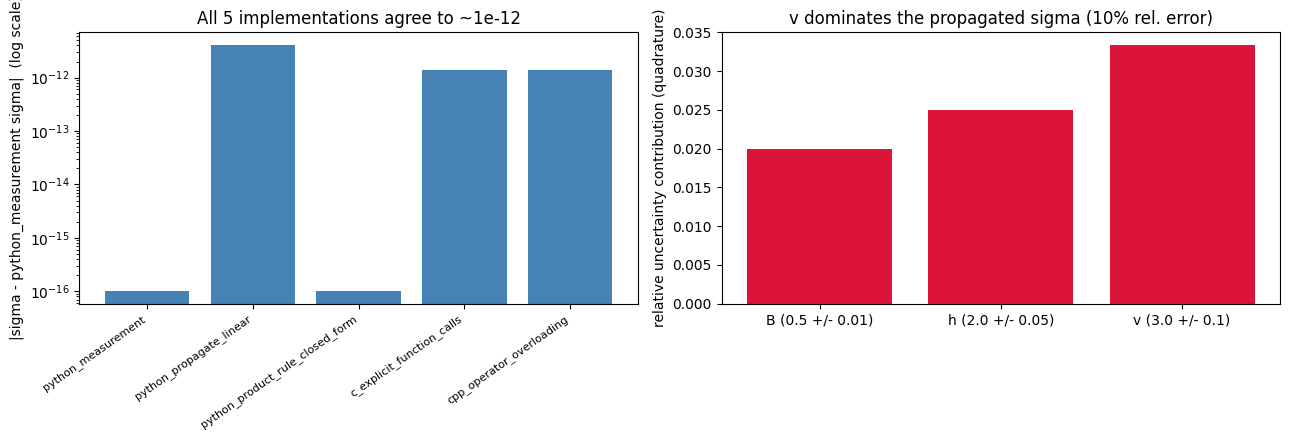

In [5]:
with tempfile.TemporaryDirectory() as tmp:
    results2 = epp.cross_validate_languages(tmp)
results2.pop('max_abs_diff_across_all_implementations')
names = list(results2.keys())
sigmas = [results2[n][1] for n in names]
ref_sigma = sigmas[0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(range(len(names)), [abs(s - ref_sigma) + 1e-16 for s in sigmas], color='steelblue')
axes[0].set_yscale('log')
axes[0].set_xticks(range(len(names)))
axes[0].set_xticklabels(names, rotation=35, ha='right', fontsize=8)
axes[0].set_ylabel('|sigma - python_measurement sigma|  (log scale)')
axes[0].set_title('All 5 implementations agree to ~1e-12')

B, h, v = (0.5, 0.01), (2.0, 0.05), (3.0, 0.1)
rel = {'B (0.5 +/- 0.01)': (B[1]/B[0])**2, 'h (2.0 +/- 0.05)': (h[1]/h[0])**2, 'v (3.0 +/- 0.1)': (v[1]/v[0])**2}
labels, vals = list(rel.keys()), list(rel.values())
axes[1].bar(labels, [np.sqrt(x) for x in vals], color='crimson')
axes[1].set_ylabel('relative uncertainty contribution (quadrature)')
axes[1].set_title('v dominates the propagated sigma (10% rel. error)')
plt.tight_layout()
plt.savefig('error_propagation_polyglot_agreement.png', dpi=100, bbox_inches='tight')
plt.show()


## 5. Engineering Interpretation

- The `<1e-9` cross-language agreement (section 3) is the actual proof this
  notebook's central claim is true: a "faithful translation" between C,
  C++, and Python is a claim that has to be CHECKED against real compiled
  output, the same discipline `dgs/circuits_polyglot.py` and
  `dgs/matmul_benchmark.py` already apply to numerical algorithms -- here
  applied to a language-DESIGN claim instead of a physics one.
- The C version's `measurement_mul` returning a `struct Measurement` BY
  VALUE is doing real work: it's C's only mechanism for "return a compound
  result," and it's exactly what C++'s `operator*` does under the hood too
  (return a new object by value) -- operator overloading doesn't change the
  underlying mechanism, only what syntax can invoke it.
- `dgs/error_propagation.py`'s `Measurement` class already showed Python
  has this feature; this notebook's contribution is showing WHICH of C and
  C++ also have it, and confirming (not assuming) that the presence or
  absence of the feature doesn't change the numerics.


## 6. Research Discussion

- `dgs/error_propagation.py`'s `Measurement` correctly notes it does NOT
  track correlation (treats every combination as independent). Could a C++
  `Measurement` class with a `static thread_local` correlation registry (or
  a small `CovarianceMatrix` companion class) track correlations
  automatically through `operator*`, something C's function-call style
  would need an explicit extra parameter for at every call site?
- Section 4's plot shows `v` dominates the propagated uncertainty. Could
  `dgs/error_propagation.py`'s `jacobian()` (already numerical, works for
  ANY `f`) be ported to C++ with `operator()` (making a `Measurement`
  object itself callable) to auto-differentiate propagation through a
  black-box formula, rather than only through hand-written `operator*`/`+`?
- Is there a MEASURABLE runtime cost to C++ operator overloading here
  (extra function-call overhead, or does `-O2` inline it away identically
  to C's explicit call)? `dgs/matmul_benchmark.py` already has the
  benchmarking harness pattern to check this empirically instead of
  assuming "zero-cost abstraction" holds.


## 7. Problems to Solve in Computer Engineering

Extending the C-vs-C++ formalism contrast from "can I write `a*b`?" into
territory that actually matters for embedded/systems computer engineering:
type systems, failure-mode propagation, fixed-point arithmetic, generics,
and concurrency. Roughly increasing difficulty.

1. **Add `+`/`-` and a batch/array version.** Extend `measurement_mul` (C)
   and `operator*` (C++) with `measurement_add`/`operator+` matching
   `Measurement.__add__`'s add-in-quadrature rule. Then propagate
   uncertainty through an ARRAY of N independent measurements -- a C loop
   over a `struct Measurement[]` vs. a C++ `std::vector<Measurement>` with
   `std::accumulate` using the overloaded operators. Compare line counts.

2. **Correlated inputs via a covariance matrix.** `dgs/error_propagation.py`'s
   `propagate()` already supports a full covariance `Sigma` (not just
   independent sigmas). Implement the correlated case
   ($\sigma_f^2=g^T\Sigma g$) in C (explicit nested loops over a
   flattened matrix) and in C++ (a small `Matrix` class with an overloaded
   `operator*` for matrix-vector products) -- does the LOC gap between the
   two languages widen for this harder case, compared to the simple
   product rule above?

3. **Failure-mode propagation, not just numeric propagation.** A
   `Measurement` constructed with `sigma < 0` or a division by a
   zero-value `Measurement` is invalid. Implement the C path with an
   explicit `errno`-style return code (or a `Measurement_or_error` tagged
   union) that the CALLER must check, and the C++ path by `throw`ing a
   custom `std::exception` subclass caught with `try`/`catch` (RAII
   unwinding through any partially-constructed objects on the stack).
   Verify with a fuzz test that the C path never silently continues on an
   unchecked error, and the C++ path never leaks a resource mid-unwind.

4. **Fixed-point (embedded, no-FPU) uncertainty propagation.** Many
   microcontrollers have no hardware floating point. Reimplement
   `measurement_mul` in C using Q15 or Q31 fixed-point integers instead of
   `double`, and measure how much EXTRA error the fixed-point
   QUANTIZATION itself contributes on top of the physical measurement
   uncertainty already being propagated -- a genuinely different error
   source than the statistical one this notebook otherwise tracks.

5. **Generics: C++ templates vs. C's lack of them.** Make a
   `template<typename T> class Measurement` in C++ that works for `float`,
   `double`, AND a custom fixed-point type from problem 4 without
   duplicating code. In C (no templates), implement the same generality
   with X-macros or `void*` + function pointers, and assess how much
   compile-time type safety is lost in the process.

6. **Concurrency.** Propagate uncertainty for N independent measurement
   chains in parallel: `pthread_create`/`pthread_join` with explicit
   `struct` argument-passing in C, vs. `std::async`/`std::future` (RAII-
   managed) in C++. Benchmark wall-clock time for N=1000 chains and compare
   the amount of manual bookkeeping (thread handles, joins, error checking)
   each language formalism requires for the identical parallel workload.


## 8. Future Improvements

- `cross_validate_languages` currently compares only the FINAL emf value
  and sigma. A stronger check would compare intermediate values too (e.g.
  the `B*h` sub-product before the final `*v`), catching a bug that
  happens to cancel out by the last step.
- Add a fourth language (Rust, with its `Add`/`Mul` traits -- a THIRD
  formalism for operator overloading, trait-based rather than
  class-method-based like C++ or Python) to see whether the trait
  mechanism changes anything numerically (it shouldn't, by this notebook's
  own thesis) or only stylistically.
